# 1. Importação

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('bq-results-20260904-205126-1788555238314.csv')
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# 2. Validação

## 2.1 Estrutura geral

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23439 entries, 0 to 23438
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   report_date                  23439 non-null  object 
 1   campaign_key                 23439 non-null  object 
 2   campaign_name                23439 non-null  object 
 3   platform                     23439 non-null  object 
 4   campaign_group               23439 non-null  object 
 5   funnel_stage                 23439 non-null  object 
 6   campaign_key_type            23439 non-null  object 
 7   receita                      14134 non-null  float64
 8   orders                       14134 non-null  float64
 9   visits                       14134 non-null  float64
 10  investimento                 17290 non-null  float64
 11  impressions                  17263 non-null  float64
 12  clicks                       16929 non-null  float64
 13  roas            

In [4]:
df.shape

(23439, 29)

## 2.2 Duplicados

Sem duplicados.

In [5]:
df.duplicated().sum()

np.int64(0)

## 2.3 Valores nulos e 'NÃO IDENTIFICADO'

Porcentagem de valores nulos por variável

In [6]:
df.isnull().sum()

report_date                        0
campaign_key                       0
campaign_name                      0
platform                           0
campaign_group                     0
funnel_stage                       0
campaign_key_type                  0
receita                         9305
orders                          9305
visits                          9305
investimento                    6149
impressions                     6176
clicks                          6510
roas                           15712
receita_safe_ad                 9305
receita_excecao_manual          9305
receita_pmax_sem_anuncio        9305
receita_por_nome_campanha       9305
receita_outro                   9305
receita_anuncio_ambiguo         9305
receita_nao_casado              9305
investimento_anuncio            6100
investimento_campanha           6149
pct_receita_assertiva          16960
pct_receita_anuncio_ambiguo    16960
pct_receita_assertiva_alta     16960
pct_investimento_anuncio        7370
m

In [7]:
(df.isnull().sum() / len(df)) * 100

report_date                    0.00
campaign_key                   0.00
campaign_name                  0.00
platform                       0.00
campaign_group                 0.00
funnel_stage                   0.00
campaign_key_type              0.00
receita                       39.70
orders                        39.70
visits                        39.70
investimento                  26.23
impressions                   26.35
clicks                        27.77
roas                          67.03
receita_safe_ad               39.70
receita_excecao_manual        39.70
receita_pmax_sem_anuncio      39.70
receita_por_nome_campanha     39.70
receita_outro                 39.70
receita_anuncio_ambiguo       39.70
receita_nao_casado            39.70
investimento_anuncio          26.03
investimento_campanha         26.23
pct_receita_assertiva         72.36
pct_receita_anuncio_ambiguo   72.36
pct_receita_assertiva_alta    72.36
pct_investimento_anuncio      31.44
motivos_receita             

Porcentagem de valores 'NÃO IDENTIFICADO' em todas as variáveis

In [8]:
porcentagem_nao_id = (df == 'NÃO IDENTIFICADO').mean() * 100
print(porcentagem_nao_id[porcentagem_nao_id > 0])

campaign_name     2.58
campaign_group   18.67
funnel_stage     16.92
dtype: float64


## 2.4 Nulos de receita por plataforma

In [9]:
total_linhas_plataforma = df.groupby('platform').size()
nulos_receita = df[df['receita'].isnull()]
nulos_por_plataforma = nulos_receita.groupby('platform').size()

pct_nulo_plataforma = (nulos_por_plataforma / total_linhas_plataforma * 100).fillna(0)
pct_nulo_plataforma.sort_values(ascending=False)

platform
Awin         100.00
Kayak        100.00
Skyscanner   100.00
DV360         82.00
Vivo          68.52
RTB           59.68
Criteo        35.38
Bing Ads      32.62
Meta Ads      24.36
Google Ads    14.23
UOL            6.18
Taboola        1.23
dtype: float64

Qual etapa do funil a receita nula faz parte

In [10]:
nulos_receita = df[df['receita'].isnull()]

tab = nulos_receita.groupby(['platform', 'funnel_stage']).size().unstack(fill_value=0)
tab

funnel_stage,Awareness,Consideração,Conversão,NÃO IDENTIFICADO
platform,,,,
Awin,0,0,302,0
Bing Ads,0,0,1724,0
Criteo,0,0,74,24
DV360,0,0,41,0
Google Ads,167,559,490,0
Kayak,0,0,107,3681
Meta Ads,25,18,331,0
RTB,0,213,308,37
Skyscanner,0,0,751,225


Maioria da receita nula está concentrada em Kaiak e 'NÃO IDENTIFICADO'

In [11]:
df[df['platform'] == 'DV360']['receita'].value_counts(dropna=False)

receita
NaN     41
0.00     9
Name: count, dtype: int64

In [12]:

rtb_nao_id = df[(df['platform'] == 'RTB') & (df['funnel_stage'] == 'NÃO IDENTIFICADO')]
rtb_nao_id.head()

,report_date,campaign_key,campaign_name,platform,campaign_group,funnel_stage,campaign_key_type,receita,orders,visits,...,receita_anuncio_ambiguo,receita_nao_casado,investimento_anuncio,investimento_campanha,pct_receita_assertiva,pct_receita_anuncio_ambiguo,pct_receita_assertiva_alta,pct_investimento_anuncio,motivos_receita,motivos_investimento
13364,2026-05-31,name|azul|rtb|não identificado,NÃO IDENTIFICADO,RTB,NÃO IDENTIFICADO,NÃO IDENTIFICADO,name,NaN,NaN,NaN,...,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15574,2026-06-22,name|azul|rtb|quality traffic,QUALITY TRAFFIC,RTB,NÃO IDENTIFICADO,NÃO IDENTIFICADO,name,NaN,NaN,NaN,...,NaN,NaN,0.00,10304.23,NaN,NaN,NaN,0.00,NaN,campanha
15652,2026-06-23,name|azul|rtb|quality traffic,QUALITY TRAFFIC,RTB,NÃO IDENTIFICADO,NÃO IDENTIFICADO,name,NaN,NaN,NaN,...,NaN,NaN,0.00,4614.26,NaN,NaN,NaN,0.00,NaN,campanha
15755,2026-06-24,name|azul|rtb|quality traffic,QUALITY TRAFFIC,RTB,NÃO IDENTIFICADO,NÃO IDENTIFICADO,name,NaN,NaN,NaN,...,NaN,NaN,0.00,1485.04,NaN,NaN,NaN,0.00,NaN,campanha
15894,2026-06-25,name|azul|rtb|quality traffic,QUALITY TRAFFIC,RTB,NÃO IDENTIFICADO,NÃO IDENTIFICADO,name,NaN,NaN,NaN,...,NaN,NaN,0.00,1190.03,NaN,NaN,NaN,0.00,NaN,campanha


In [13]:
rtb_nao_id['receita'].unique()

array([nan])

In [14]:
kayak_nao_id = df[(df['platform'] == 'Skyscanner') & (df['funnel_stage'] == 'NÃO IDENTIFICADO')]
kayak_nao_id.head()

,report_date,campaign_key,campaign_name,platform,campaign_group,funnel_stage,campaign_key_type,receita,orders,visits,...,receita_anuncio_ambiguo,receita_nao_casado,investimento_anuncio,investimento_campanha,pct_receita_assertiva,pct_receita_anuncio_ambiguo,pct_receita_assertiva_alta,pct_investimento_anuncio,motivos_receita,motivos_investimento
3063,2026-01-01,name|azul|skyscanner|br | premium iab + mobile...,BR | PREMIUM IAB + MOBILE | ROS,Skyscanner,NÃO IDENTIFICADO,NÃO IDENTIFICADO,name,NaN,NaN,NaN,...,NaN,NaN,0.00,3327.53,NaN,NaN,NaN,0.00,NaN,campanha
3104,2026-01-02,name|azul|skyscanner|br | premium iab + mobile...,BR | PREMIUM IAB + MOBILE | ROS,Skyscanner,NÃO IDENTIFICADO,NÃO IDENTIFICADO,name,NaN,NaN,NaN,...,NaN,NaN,0.00,5658.32,NaN,NaN,NaN,0.00,NaN,campanha
3143,2026-01-03,name|azul|skyscanner|br | premium iab + mobile...,BR | PREMIUM IAB + MOBILE | ROS,Skyscanner,NÃO IDENTIFICADO,NÃO IDENTIFICADO,name,NaN,NaN,NaN,...,NaN,NaN,0.00,4368.29,NaN,NaN,NaN,0.00,NaN,campanha
3181,2026-01-04,name|azul|skyscanner|br | premium iab + mobile...,BR | PREMIUM IAB + MOBILE | ROS,Skyscanner,NÃO IDENTIFICADO,NÃO IDENTIFICADO,name,NaN,NaN,NaN,...,NaN,NaN,0.00,4467.14,NaN,NaN,NaN,0.00,NaN,campanha
3224,2026-01-05,name|azul|skyscanner|br | premium iab + mobile...,BR | PREMIUM IAB + MOBILE | ROS,Skyscanner,NÃO IDENTIFICADO,NÃO IDENTIFICADO,name,NaN,NaN,NaN,...,NaN,NaN,0.00,4450.95,NaN,NaN,NaN,0.00,NaN,campanha


In [15]:
kayak_nao_id['receita'].unique()

array([nan])

In [16]:
sky_nao_id = df[(df['platform'] == 'Skyscanner') & (df['funnel_stage'] == 'NÃO IDENTIFICADO')]
sky_nao_id.head()

,report_date,campaign_key,campaign_name,platform,campaign_group,funnel_stage,campaign_key_type,receita,orders,visits,...,receita_anuncio_ambiguo,receita_nao_casado,investimento_anuncio,investimento_campanha,pct_receita_assertiva,pct_receita_anuncio_ambiguo,pct_receita_assertiva_alta,pct_investimento_anuncio,motivos_receita,motivos_investimento
3063,2026-01-01,name|azul|skyscanner|br | premium iab + mobile...,BR | PREMIUM IAB + MOBILE | ROS,Skyscanner,NÃO IDENTIFICADO,NÃO IDENTIFICADO,name,NaN,NaN,NaN,...,NaN,NaN,0.00,3327.53,NaN,NaN,NaN,0.00,NaN,campanha
3104,2026-01-02,name|azul|skyscanner|br | premium iab + mobile...,BR | PREMIUM IAB + MOBILE | ROS,Skyscanner,NÃO IDENTIFICADO,NÃO IDENTIFICADO,name,NaN,NaN,NaN,...,NaN,NaN,0.00,5658.32,NaN,NaN,NaN,0.00,NaN,campanha
3143,2026-01-03,name|azul|skyscanner|br | premium iab + mobile...,BR | PREMIUM IAB + MOBILE | ROS,Skyscanner,NÃO IDENTIFICADO,NÃO IDENTIFICADO,name,NaN,NaN,NaN,...,NaN,NaN,0.00,4368.29,NaN,NaN,NaN,0.00,NaN,campanha
3181,2026-01-04,name|azul|skyscanner|br | premium iab + mobile...,BR | PREMIUM IAB + MOBILE | ROS,Skyscanner,NÃO IDENTIFICADO,NÃO IDENTIFICADO,name,NaN,NaN,NaN,...,NaN,NaN,0.00,4467.14,NaN,NaN,NaN,0.00,NaN,campanha
3224,2026-01-05,name|azul|skyscanner|br | premium iab + mobile...,BR | PREMIUM IAB + MOBILE | ROS,Skyscanner,NÃO IDENTIFICADO,NÃO IDENTIFICADO,name,NaN,NaN,NaN,...,NaN,NaN,0.00,4450.95,NaN,NaN,NaN,0.00,NaN,campanha


In [17]:
sky_nao_id['receita'].unique()

array([nan])

In [18]:
vivo_null = df[(df['platform'] == 'Vivo')]
vivo_null.head(10)

,report_date,campaign_key,campaign_name,platform,campaign_group,funnel_stage,campaign_key_type,receita,orders,visits,...,receita_anuncio_ambiguo,receita_nao_casado,investimento_anuncio,investimento_campanha,pct_receita_assertiva,pct_receita_anuncio_ambiguo,pct_receita_assertiva_alta,pct_investimento_anuncio,motivos_receita,motivos_investimento
10917,2026-05-05,name|azul|vivo|brv_va_vivo_adtab_lf_novas-rota...,BRV_VA_VIVO_ADTAB_LF_NOVAS-ROTAS_PASS,Vivo,NOVAS-ROTAS,Conversão,name,NaN,NaN,NaN,...,NaN,NaN,0.00,1518.72,NaN,NaN,NaN,0.00,NaN,campanha
10947,2026-05-05,name|azul|vivo|brv_va_vivo_display_lf_data-dup...,BRV_VA_VIVO_DISPLAY_LF_DATA-DUPLA_PASS,Vivo,DATA-DUPLA,Conversão,name,NaN,NaN,NaN,...,NaN,NaN,0.00,23953.68,NaN,NaN,NaN,0.00,NaN,campanha
10949,2026-05-05,name|azul|vivo|brv_va_vivo_display_lf_parintin...,BRV_VA_VIVO_DISPLAY_LF_PARINTINS_PASS,Vivo,PARINTINS,Conversão,name,NaN,NaN,NaN,...,NaN,NaN,0.00,1061.18,NaN,NaN,NaN,0.00,NaN,campanha
10951,2026-05-05,name|azul|vivo|brv_va_vivo_display_lf_copa-do-...,BRV_VA_VIVO_DISPLAY_LF_COPA-DO-MUNDO_PASS,Vivo,COPA-DO-MUNDO,Conversão,name,NaN,NaN,NaN,...,NaN,NaN,0.00,508.51,NaN,NaN,NaN,0.00,NaN,campanha
11012,2026-05-06,name|azul|vivo|brv_va_vivo_display_lf_copa-do-...,BRV_VA_VIVO_DISPLAY_LF_COPA-DO-MUNDO_PASS,Vivo,COPA-DO-MUNDO,Conversão,name,NaN,NaN,NaN,...,NaN,NaN,0.00,464.83,NaN,NaN,NaN,0.00,NaN,campanha
11013,2026-05-06,name|azul|vivo|brv_va_vivo_display_lf_data-dup...,BRV_VA_VIVO_DISPLAY_LF_DATA-DUPLA_PASS,Vivo,DATA-DUPLA,Conversão,name,NaN,NaN,NaN,...,NaN,NaN,0.00,153.34,NaN,NaN,NaN,0.00,NaN,campanha
11019,2026-05-06,name|azul|vivo|brv_va_vivo_display_lf_parintin...,BRV_VA_VIVO_DISPLAY_LF_PARINTINS_PASS,Vivo,PARINTINS,Conversão,name,NaN,NaN,NaN,...,NaN,NaN,0.00,835.13,NaN,NaN,NaN,0.00,NaN,campanha
11046,2026-05-06,name|azul|vivo|brv_va_vivo_adtab_lf_novas-rota...,BRV_VA_VIVO_ADTAB_LF_NOVAS-ROTAS_PASS,Vivo,NOVAS-ROTAS,Conversão,name,NaN,NaN,NaN,...,NaN,NaN,0.00,1483.16,NaN,NaN,NaN,0.00,NaN,campanha
11097,2026-05-07,name|azul|vivo|brv_va_vivo_display_lf_parintin...,BRV_VA_VIVO_DISPLAY_LF_PARINTINS_PASS,Vivo,PARINTINS,Conversão,name,NaN,NaN,NaN,...,NaN,NaN,0.00,979.55,NaN,NaN,NaN,0.00,NaN,campanha
11107,2026-05-07,name|azul|vivo|brv_va_vivo_adtab_lf_novas-rota...,BRV_VA_VIVO_ADTAB_LF_NOVAS-ROTAS_PASS,Vivo,NOVAS-ROTAS,Conversão,name,NaN,NaN,NaN,...,NaN,NaN,0.00,1740.13,NaN,NaN,NaN,0.00,NaN,campanha


In [19]:
vivo_null['receita'].unique()

array([    nan,    0.  , 1314.42])

In [20]:
bing_null = df[(df['platform'] == 'Bing Ads')]
bing_null.head(10)

,report_date,campaign_key,campaign_name,platform,campaign_group,funnel_stage,campaign_key_type,receita,orders,visits,...,receita_anuncio_ambiguo,receita_nao_casado,investimento_anuncio,investimento_campanha,pct_receita_assertiva,pct_receita_anuncio_ambiguo,pct_receita_assertiva_alta,pct_investimento_anuncio,motivos_receita,motivos_investimento
13,2025-11-03,name|azul|bing ads|brv_va_bing_search_lf_eua-p...,BRV_VA_BING_SEARCH_LF_EUA-PASSENGER_PASS,Bing Ads,EUA-PASSENGER,Conversão,name,NaN,NaN,NaN,...,NaN,NaN,0.00,2037.54,NaN,NaN,NaN,0.00,NaN,campanha
17,2025-11-03,name|azul|bing ads|brv_va_bing_search_lf_marca...,BRV_VA_BING_SEARCH_LF_MARCA_PASS,Bing Ads,MARCA,Conversão,name,NaN,NaN,NaN,...,NaN,NaN,0.00,20484.42,NaN,NaN,NaN,0.00,NaN,campanha
18,2025-11-03,name|azul|bing ads|brv_va_bing_search_lf_conco...,BRV_VA_BING_SEARCH_LF_CONCORRENTES_PASS,Bing Ads,CONCORRENTES,Conversão,name,NaN,NaN,NaN,...,NaN,NaN,0.00,18339.67,NaN,NaN,NaN,0.00,NaN,campanha
20,2025-11-03,name|azul|bing ads|brv_va_bing_search_lf_gener...,BRV_VA_BING_SEARCH_LF_GENERICA_PASS,Bing Ads,GENERICA,Conversão,name,NaN,NaN,NaN,...,NaN,NaN,0.00,5908.43,NaN,NaN,NaN,0.00,NaN,campanha
21,2025-11-03,name|azul|bing ads|brv_va_bing_search_lf_inter...,BRV_VA_BING_SEARCH_LF_INTERNACIONAL_PASS,Bing Ads,INTERNACIONAL,Conversão,name,NaN,NaN,NaN,...,NaN,NaN,0.00,6682.18,NaN,NaN,NaN,0.00,NaN,campanha
27,2025-11-03,name|azul|bing ads|brv_va_bing_dmax_lf_aon_pass,BRV_VA_BING_DMAX_LF_AON_PASS,Bing Ads,AON,Conversão,name,NaN,NaN,NaN,...,NaN,NaN,0.00,6360.52,NaN,NaN,NaN,0.00,NaN,campanha
40,2025-11-04,name|azul|bing ads|brv_va_bing_search_lf_inter...,BRV_VA_BING_SEARCH_LF_INTERNACIONAL_PASS,Bing Ads,INTERNACIONAL,Conversão,name,NaN,NaN,NaN,...,NaN,NaN,0.00,6670.74,NaN,NaN,NaN,0.00,NaN,campanha
47,2025-11-04,name|azul|bing ads|brv_va_bing_search_lf_eua-p...,BRV_VA_BING_SEARCH_LF_EUA-PASSENGER_PASS,Bing Ads,EUA-PASSENGER,Conversão,name,NaN,NaN,NaN,...,NaN,NaN,0.00,2055.97,NaN,NaN,NaN,0.00,NaN,campanha
49,2025-11-04,name|azul|bing ads|brv_va_bing_search_lf_conco...,BRV_VA_BING_SEARCH_LF_CONCORRENTES_PASS,Bing Ads,CONCORRENTES,Conversão,name,NaN,NaN,NaN,...,NaN,NaN,0.00,18442.77,NaN,NaN,NaN,0.00,NaN,campanha
50,2025-11-04,name|azul|bing ads|brv_va_bing_search_lf_marca...,BRV_VA_BING_SEARCH_LF_MARCA_PASS,Bing Ads,MARCA,Conversão,name,NaN,NaN,NaN,...,NaN,NaN,0.00,19834.04,NaN,NaN,NaN,0.00,NaN,campanha


In [21]:
bing_null['receita'].unique()

array([     nan,     0.  , 10843.65, ...,  4037.68,  1877.97,   571.45],
      shape=(2177,))

In [22]:
awin_null = df[(df['platform'] == 'Awin')]
awin_null.head()

,report_date,campaign_key,campaign_name,platform,campaign_group,funnel_stage,campaign_key_type,receita,orders,visits,...,receita_anuncio_ambiguo,receita_nao_casado,investimento_anuncio,investimento_campanha,pct_receita_assertiva,pct_receita_anuncio_ambiguo,pct_receita_assertiva_alta,pct_investimento_anuncio,motivos_receita,motivos_investimento
12,2025-11-03,name|azul|awin|não identificado,NÃO IDENTIFICADO,Awin,NÃO IDENTIFICADO,Conversão,name,NaN,NaN,NaN,...,NaN,NaN,0.00,10514.00,NaN,NaN,NaN,0.00,NaN,campanha
43,2025-11-04,name|azul|awin|não identificado,NÃO IDENTIFICADO,Awin,NÃO IDENTIFICADO,Conversão,name,NaN,NaN,NaN,...,NaN,NaN,0.00,8188.07,NaN,NaN,NaN,0.00,NaN,campanha
81,2025-11-05,name|azul|awin|não identificado,NÃO IDENTIFICADO,Awin,NÃO IDENTIFICADO,Conversão,name,NaN,NaN,NaN,...,NaN,NaN,0.00,10081.98,NaN,NaN,NaN,0.00,NaN,campanha
112,2025-11-06,name|azul|awin|não identificado,NÃO IDENTIFICADO,Awin,NÃO IDENTIFICADO,Conversão,name,NaN,NaN,NaN,...,NaN,NaN,0.00,9254.09,NaN,NaN,NaN,0.00,NaN,campanha
139,2025-11-07,name|azul|awin|não identificado,NÃO IDENTIFICADO,Awin,NÃO IDENTIFICADO,Conversão,name,NaN,NaN,NaN,...,NaN,NaN,0.00,12252.89,NaN,NaN,NaN,0.00,NaN,campanha


In [23]:
awin_null['receita'].unique()

array([nan])

In [24]:
nulos_receita = df[df['investimento'].isnull()]

tab = nulos_receita.groupby(['platform', 'funnel_stage']).size().unstack(fill_value=0)
tab

funnel_stage,Consideração,Conversão,NÃO IDENTIFICADO
platform,,,
Bing Ads,0,1968,0
Criteo,0,111,0
Google Ads,328,2446,0
Kayak,0,0,48
Meta Ads,0,208,0
RTB,0,233,1
Taboola,0,394,0
UOL,0,353,0
Vivo,0,59,0


In [25]:
df.groupby('platform')['receita'].unique()

platform
Awin                                                      [nan]
Bing Ads      [nan, 0.0, 10843.65, 2249.43, 401345.26, 23400...
Criteo        [435.68, nan, 0.0, 13459.81, 6449.24, 27196.2,...
DV360                                                [nan, 0.0]
Google Ads    [20696.29, 5602.07, 4802.02, 3594.36, 3082.61,...
Kayak                                                     [nan]
Meta Ads      [nan, 0.0, 7114.16, 2621.08, 1241.95, 2304.18,...
RTB           [nan, 0.0, 172.49, 1966.36, 1104.42, 2630.52, ...
Skyscanner                                                [nan]
Taboola       [0.0, 2306.84, 462.98, 541.78, 386.07, 4165.23...
UOL           [1289.59, 6427.4, 0.0, 332.06, 33.56, 365.26, ...
Vivo                                        [nan, 0.0, 1314.42]
Name: receita, dtype: object

Awin, Kayak, Skyscanner têm todas as linhas com receita nula, só retornam cliques, impressões e investimento, para análise da receita serão desconsideradas.

DV360 retorna apenas 0.0 e nulos

Vivo tem apenas um valor diferente de 0.o ou nulo

Vivo e DV360 também serão desconsiderados



In [26]:
plataformas_sem_receita = ['Awin', 'Kayak', 'Skyscanner', 'DV360', 'Vivo']
df_receita = df[~df['platform'].isin(plataformas_sem_receita)]

In [27]:
df_receita['platform'].unique()

array(['Google Ads', 'Bing Ads', 'RTB', 'Meta Ads', 'UOL', 'Taboola',
       'Criteo'], dtype=object)

In [28]:
total_por_grupo = df.groupby(['platform', 'funnel_stage']).size()
nulos_por_grupo = nulos_receita.groupby(['platform', 'funnel_stage']).size()

pct_nulo_grupo = (nulos_por_grupo / total_por_grupo * 100).dropna().sort_values(ascending=False)
pct_nulo_grupo

platform    funnel_stage    
UOL         Conversão          70.32
Criteo      Conversão          43.87
Taboola     Conversão          40.37
Bing Ads    Conversão          37.24
Google Ads  Consideração       35.01
RTB         Conversão          34.01
Google Ads  Conversão          32.91
Vivo        Conversão          21.85
Meta Ads    Conversão          13.94
RTB         NÃO IDENTIFICADO    2.70
Kayak       NÃO IDENTIFICADO    1.30
dtype: float64

## 2.5 Exploração variáveis

In [29]:
df["campaign_key"].value_counts().head(20)

campaign_key
name|azul|bing ads|brv_va_bing_search_lf_marca_pass                          302
id|azul|google ads|20417584768                                               302
id|azul|google ads|18482497357                                               302
name|azul|kayak|não identificado                                             302
name|azul|awin|não identificado                                              302
id|azul|google ads|6504006924                                                302
id|azul|google ads|11382534426                                               302
name|azul|bing ads|brv_va_bing_dmax_lf_aon_pass                              301
name|azul|bing ads|brv_va_bing_search_lf_concorrentes_pass                   299
id|azul|google ads|20508311506                                               298
id|azul|google ads|18185234105                                               293
name|azul|bing ads|brv_va_bing_search_lf_internacional_pass                  291
id|azul|google 

In [30]:
df["receita"].value_counts().head(20)

receita
0.00       7655
95.70         4
100.44        4
105.05        4
70.30         4
54.45         4
92.62         3
222.66        3
204.08        3
62.62         3
101.84        3
33.64         3
130.44        3
129.36        3
245.24        3
189.12        2
1869.24       2
190.02        2
190.46        2
112.62        2
Name: count, dtype: int64

In [31]:
df["motivos_investimento"].value_counts()

motivos_investimento
campanha              10211
anuncio                4882
anuncio + campanha      976
Name: count, dtype: int64

In [32]:
df["report_date"].value_counts().head(20)

report_date
2026-06-24    121
2026-07-15    120
2026-07-16    119
2026-07-13    119
2026-07-21    119
2026-07-08    118
2026-07-14    118
2026-08-04    117
2026-07-20    117
2026-07-02    117
2026-08-27    117
2026-08-10    117
2026-07-01    116
2026-07-24    116
2026-08-28    116
2026-08-12    116
2026-08-20    116
2026-07-06    115
2026-06-28    115
2026-08-31    115
Name: count, dtype: int64

In [33]:
df["platform"].value_counts()

platform
Google Ads    8543
Bing Ads      5285
Kayak         3788
Meta Ads      1535
Skyscanner     976
Taboola        976
RTB            935
UOL            502
Awin           302
Criteo         277
Vivo           270
DV360           50
Name: count, dtype: int64

In [34]:
df["roas"].value_counts().head(20)

roas
0.00    3305
0.03       1
0.22       1
2.66       1
1.41       1
0.10       1
0.12       1
0.57       1
1.37       1
0.76       1
0.19       1
0.38       1
3.89       1
1.68       1
0.65       1
4.47       1
0.07       1
0.08       1
1.44       1
1.70       1
Name: count, dtype: int64

# 3. Tratamento

## 3.1 Datas

In [35]:
df['report_date'] = df['report_date'].str.strip()
df["report_date"] = pd.to_datetime(df["report_date"], format="%Y-%m-%d")

In [36]:
df.isnull().sum()

report_date                        0
campaign_key                       0
campaign_name                      0
platform                           0
campaign_group                     0
funnel_stage                       0
campaign_key_type                  0
receita                         9305
orders                          9305
visits                          9305
investimento                    6149
impressions                     6176
clicks                          6510
roas                           15712
receita_safe_ad                 9305
receita_excecao_manual          9305
receita_pmax_sem_anuncio        9305
receita_por_nome_campanha       9305
receita_outro                   9305
receita_anuncio_ambiguo         9305
receita_nao_casado              9305
investimento_anuncio            6100
investimento_campanha           6149
pct_receita_assertiva          16960
pct_receita_anuncio_ambiguo    16960
pct_receita_assertiva_alta     16960
pct_investimento_anuncio        7370
m

In [37]:
df_receita.isnull().sum() 

report_date                        0
campaign_key                       0
campaign_name                      0
platform                           0
campaign_group                     0
funnel_stage                       0
campaign_key_type                  0
receita                         4013
orders                          4013
visits                          4013
investimento                    6042
impressions                     6117
clicks                          6398
roas                           10361
receita_safe_ad                 4013
receita_excecao_manual          4013
receita_pmax_sem_anuncio        4013
receita_por_nome_campanha       4013
receita_outro                   4013
receita_anuncio_ambiguo         4013
receita_nao_casado              4013
investimento_anuncio            6041
investimento_campanha           6042
pct_receita_assertiva          11575
pct_receita_anuncio_ambiguo    11575
pct_receita_assertiva_alta     11575
pct_investimento_anuncio        6621
m

In [38]:
(df_receita.isnull().sum() / len(df_receita)) * 100

report_date                    0.00
campaign_key                   0.00
campaign_name                  0.00
platform                       0.00
campaign_group                 0.00
funnel_stage                   0.00
campaign_key_type              0.00
receita                       22.23
orders                        22.23
visits                        22.23
investimento                  33.47
impressions                   33.88
clicks                        35.44
roas                          57.39
receita_safe_ad               22.23
receita_excecao_manual        22.23
receita_pmax_sem_anuncio      22.23
receita_por_nome_campanha     22.23
receita_outro                 22.23
receita_anuncio_ambiguo       22.23
receita_nao_casado            22.23
investimento_anuncio          33.46
investimento_campanha         33.47
pct_receita_assertiva         64.12
pct_receita_anuncio_ambiguo   64.12
pct_receita_assertiva_alta    64.12
pct_investimento_anuncio      36.68
motivos_receita             

In [39]:
df_receita_sem_pct = df_receita.drop(columns=['pct_receita_assertiva', 'pct_receita_anuncio_ambiguo', 'pct_receita_assertiva_alta', 'pct_investimento_anuncio'])

In [40]:
(df_receita_sem_pct.isnull().sum() / len(df_receita)) * 100

report_date                  0.00
campaign_key                 0.00
campaign_name                0.00
platform                     0.00
campaign_group               0.00
funnel_stage                 0.00
campaign_key_type            0.00
receita                     22.23
orders                      22.23
visits                      22.23
investimento                33.47
impressions                 33.88
clicks                      35.44
roas                        57.39
receita_safe_ad             22.23
receita_excecao_manual      22.23
receita_pmax_sem_anuncio    22.23
receita_por_nome_campanha   22.23
receita_outro               22.23
receita_anuncio_ambiguo     22.23
receita_nao_casado          22.23
investimento_anuncio        33.46
investimento_campanha       33.47
motivos_receita             22.23
motivos_investimento        36.68
dtype: float64

Como o objetivo da análise é analisar oque afeta a receita vão ser desconsideradas as variáveis de porcentagem.

In [41]:
df_receita_sem_pct.head()

,report_date,campaign_key,campaign_name,platform,campaign_group,funnel_stage,campaign_key_type,receita,orders,visits,...,receita_excecao_manual,receita_pmax_sem_anuncio,receita_por_nome_campanha,receita_outro,receita_anuncio_ambiguo,receita_nao_casado,investimento_anuncio,investimento_campanha,motivos_receita,motivos_investimento
0,2025-11-03,id|azul|google ads|6504006924,BRV_VA_GOOGLE_SEARCH_LF_AON-MARCA-BRD_PASS,Google Ads,AON-MARCA-BRD,Conversão,id,20696.29,42.00,731.00,...,0.00,0.00,0.00,0.00,0.00,0.00,36402.57,0.00,safe_ad,anuncio
1,2025-11-03,id|azul|google ads|18482497357,BRV_VA_GOOGLE_SEARCH_LF_AON-CONCORRENTES-NBRD_...,Google Ads,AON-CONCORRENTES-NBRD,Conversão,id,5602.07,4.00,344.00,...,0.00,5602.07,0.00,0.00,0.00,0.00,51233.72,0.00,"pmax_sem_anuncio,safe_ad",anuncio
2,2025-11-03,id|azul|google ads|20508311506,BRV_VA_GOOGLE_SEARCH_LF_AON-US-PASSENGER-BRD_PASS,Google Ads,AON-US-PASSENGER-BRD,Conversão,id,4802.02,2.00,51.00,...,0.00,0.00,0.00,0.00,0.00,0.00,3960.58,0.00,"pmax_sem_anuncio,safe_ad",anuncio
3,2025-11-03,id|azul|google ads|20417584768,BRV_VA_GOOGLE_PMAX_LF_AON-MARCA_PASS,Google Ads,AON-MARCA,Conversão,id,3594.36,6.00,194.00,...,0.00,3594.36,0.00,0.00,0.00,0.00,0.00,125452.90,pmax_sem_anuncio,campanha
4,2025-11-03,id|azul|google ads|11382534426,BRV_VA_GOOGLE_SEARCH_LF_AON-GENERICA-NBRD_PASS,Google Ads,AON-GENERICA-NBRD,Conversão,id,3082.61,3.00,479.00,...,0.00,227.53,0.00,0.00,0.00,0.00,13720.68,0.00,"pmax_sem_anuncio,safe_ad",anuncio


In [42]:
numericas_zero = [
    "receita", "orders", "visits", "investimento", "impressions", "clicks",
    "receita_safe_ad", "receita_excecao_manual", "receita_pmax_sem_anuncio",
    "receita_por_nome_campanha", "receita_outro", "receita_anuncio_ambiguo", "receita_nao_casado",
    "investimento_anuncio", "investimento_campanha",
]

df_receita_sem_pct_fill_num = df_receita_sem_pct.copy()

for col in numericas_zero:
    df_receita_sem_pct_fill_num[col] = df_receita_sem_pct_fill_num[col].fillna(0)

### Preenchimento dos nulos categóricos

In [43]:
df_receita_sem_pct_fill_num["motivos_receita"] = df_receita_sem_pct_fill_num["motivos_receita"].fillna("sem_receita")
df_receita_sem_pct_fill_num["motivos_investimento"] = df_receita_sem_pct_fill_num["motivos_investimento"].fillna("sem_investimento")

In [44]:
(df_receita_sem_pct_fill_num.isnull().sum() / len(df_receita)) * 100

report_date                  0.00
campaign_key                 0.00
campaign_name                0.00
platform                     0.00
campaign_group               0.00
funnel_stage                 0.00
campaign_key_type            0.00
receita                      0.00
orders                       0.00
visits                       0.00
investimento                 0.00
impressions                  0.00
clicks                       0.00
roas                        57.39
receita_safe_ad              0.00
receita_excecao_manual       0.00
receita_pmax_sem_anuncio     0.00
receita_por_nome_campanha    0.00
receita_outro                0.00
receita_anuncio_ambiguo      0.00
receita_nao_casado           0.00
investimento_anuncio         0.00
investimento_campanha        0.00
motivos_receita              0.00
motivos_investimento         0.00
dtype: float64

In [45]:

df_receita_sem_pct_fill_num["roas"] = df_receita_sem_pct_fill_num["receita"] / df_receita_sem_pct_fill_num["investimento"].replace(0, np.nan)
df_receita_sem_pct_fill_num["roas"] = df_receita_sem_pct_fill_num["roas"].fillna(0)
tratada = df_receita_sem_pct_fill_num

### Colunas de mês e ano

In [46]:
tratada["report_date"] = pd.to_datetime(tratada["report_date"].str.strip(), format="%Y-%m-%d")

tratada["mes"] = tratada["report_date"].dt.month
tratada["ano"] = tratada["report_date"].dt.year
tratada["ano_mes"] = tratada["report_date"].dt.to_period("M").astype(str)

In [81]:
nao_ident = tratada[tratada['funnel_stage'] == 'NÃO IDENTIFICADO'] 
tratada = tratada[tratada['funnel_stage'] != 'NÃO IDENTIFICADO']    

Como haviam apenas 61 linhas com 'funnel_stage' = 'NÃO IDENTIFICADO', e elas representavam uma porcentagem muito pequena. Foram apagadas.

## Verificação pós tratamento

In [82]:
tratada.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17992 entries, 0 to 23436
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   report_date                17992 non-null  datetime64[ns]
 1   campaign_key               17992 non-null  object        
 2   campaign_name              17992 non-null  object        
 3   platform                   17992 non-null  object        
 4   campaign_group             17992 non-null  object        
 5   funnel_stage               17992 non-null  object        
 6   campaign_key_type          17992 non-null  object        
 7   receita                    17992 non-null  float64       
 8   orders                     17992 non-null  float64       
 9   visits                     17992 non-null  float64       
 10  investimento               17992 non-null  float64       
 11  impressions                17992 non-null  float64       
 12  clicks   

In [83]:
(tratada.isnull().sum() / len(df)) * 100

report_date                 0.00
campaign_key                0.00
campaign_name               0.00
platform                    0.00
campaign_group              0.00
funnel_stage                0.00
campaign_key_type           0.00
receita                     0.00
orders                      0.00
visits                      0.00
investimento                0.00
impressions                 0.00
clicks                      0.00
roas                        0.00
receita_safe_ad             0.00
receita_excecao_manual      0.00
receita_pmax_sem_anuncio    0.00
receita_por_nome_campanha   0.00
receita_outro               0.00
receita_anuncio_ambiguo     0.00
receita_nao_casado          0.00
investimento_anuncio        0.00
investimento_campanha       0.00
motivos_receita             0.00
motivos_investimento        0.00
mes                         0.00
ano                         0.00
ano_mes                     0.00
dtype: float64

In [84]:
tratada.head()

,report_date,campaign_key,campaign_name,platform,campaign_group,funnel_stage,campaign_key_type,receita,orders,visits,...,receita_outro,receita_anuncio_ambiguo,receita_nao_casado,investimento_anuncio,investimento_campanha,motivos_receita,motivos_investimento,mes,ano,ano_mes
0,2025-11-03,id|azul|google ads|6504006924,BRV_VA_GOOGLE_SEARCH_LF_AON-MARCA-BRD_PASS,Google Ads,AON-MARCA-BRD,Conversão,id,20696.29,42.00,731.00,...,0.00,0.00,0.00,36402.57,0.00,safe_ad,anuncio,11,2025,2025-11
1,2025-11-03,id|azul|google ads|18482497357,BRV_VA_GOOGLE_SEARCH_LF_AON-CONCORRENTES-NBRD_...,Google Ads,AON-CONCORRENTES-NBRD,Conversão,id,5602.07,4.00,344.00,...,0.00,0.00,0.00,51233.72,0.00,"pmax_sem_anuncio,safe_ad",anuncio,11,2025,2025-11
2,2025-11-03,id|azul|google ads|20508311506,BRV_VA_GOOGLE_SEARCH_LF_AON-US-PASSENGER-BRD_PASS,Google Ads,AON-US-PASSENGER-BRD,Conversão,id,4802.02,2.00,51.00,...,0.00,0.00,0.00,3960.58,0.00,"pmax_sem_anuncio,safe_ad",anuncio,11,2025,2025-11
3,2025-11-03,id|azul|google ads|20417584768,BRV_VA_GOOGLE_PMAX_LF_AON-MARCA_PASS,Google Ads,AON-MARCA,Conversão,id,3594.36,6.00,194.00,...,0.00,0.00,0.00,0.00,125452.90,pmax_sem_anuncio,campanha,11,2025,2025-11
4,2025-11-03,id|azul|google ads|11382534426,BRV_VA_GOOGLE_SEARCH_LF_AON-GENERICA-NBRD_PASS,Google Ads,AON-GENERICA-NBRD,Conversão,id,3082.61,3.00,479.00,...,0.00,0.00,0.00,13720.68,0.00,"pmax_sem_anuncio,safe_ad",anuncio,11,2025,2025-11


# 4. Análise

## 4.1 Visão geral

In [85]:
tratada.describe()

,report_date,receita,orders,visits,investimento,impressions,clicks,roas,receita_safe_ad,receita_excecao_manual,receita_pmax_sem_anuncio,receita_por_nome_campanha,receita_outro,receita_anuncio_ambiguo,receita_nao_casado,investimento_anuncio,investimento_campanha,mes,ano
count,17992,17992.00,17992.00,17992.00,17992.00,17992.00,17992.00,17992.00,17992.00,17992.00,17992.00,17992.00,17992.00,17992.00,17992.00,17992.00,17992.00,17992.00,17992.00
mean,2026-05-02 06:51:18.168074752,42048.01,24.37,592.57,3096.61,133074.26,2079.70,21.22,1787.86,21816.37,3990.34,6375.61,0.00,8077.83,0.00,1905.77,1190.84,5.89,2025.89
min,2025-11-03 00:00:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,2025.00
25%,2026-03-02 00:00:00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4.00,2026.00
50%,2026-05-17 00:00:00,0.00,0.00,11.00,242.31,3886.50,148.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,6.00,2026.00
75%,2026-07-12 00:00:00,2878.88,2.00,108.00,1718.75,56083.25,842.25,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,340.58,142.29,8.00,2026.00
max,2026-08-31 00:00:00,4265516.27,2412.00,42968.00,476439.13,36101802.00,647101.00,274644.00,2097199.76,4022989.91,1137948.00,615349.35,0.00,4112059.01,0.00,476439.13,136448.00,12.00,2026.00
std,NaN,280206.84,163.02,3542.52,11907.54,653262.65,9086.64,2048.95,22438.96,230452.22,34823.28,39507.48,0.00,133787.27,0.00,10872.13,5303.35,2.88,0.32


receita - valores dispersos, segundo quartil mostra que no minimo 50% dos valores são 0
orders - 

Confirmando que `receita_outro` e `receita_nao_casado` são sempre zero:

In [86]:
tratada[["receita_outro", "receita_nao_casado"]].agg(["sum", "max"])

,receita_outro,receita_nao_casado
sum,0.00,0.00
max,0.00,0.00


In [120]:
tratada[['investimento', 'receita']].sum()

investimento    55714189.98
receita        756527794.05
dtype: float64

In [130]:
roi_bruto = tratada['receita'].sum() / tratada['investimento'].sum()
print(roi_bruto)

13.578727328513187


In [129]:
roi_liquido = (tratada['receita'].sum() - tratada['investimento'].sum()) / tratada['investimento'].sum() 
print(roi_liquido)

12.578727328513185


ROI líquido muito bom

In [141]:
plataforma_variaveis = tratada.groupby(['campaign_name', 'platform', 'funnel_stage','motivos_receita' ])[['receita', 'investimento', 'orders', 'visits', 'impressions', 'clicks']].sum()
plataforma_variaveis["roas_medio"] = plataforma_variaveis["receita"] / plataforma_variaveis["investimento"]
plataforma_variaveis.sort_values(by="roas_medio", ascending=False)

,,,,receita,investimento,orders,visits,impressions,clicks,roas_medio
campaign_name,platform,funnel_stage,motivos_receita,,,,,,,
VML_VA_GOOGLE_DISPLAY_MF_AON_PASS,Google Ads,Consideração,safe_ad,9852.74,0.00,4.00,202.00,0.00,0.00,inf
BRV_VA_UOL_DISPLAY_LF_VOADO_PASS,UOL,Conversão,por_nome_campanha,10902.94,0.00,5.00,210.00,3437134.00,3111.00,inf
BRV_VA_UOL_ADTAB_LF_DATA-DUPLA_PASS,UOL,Conversão,por_nome_campanha,2480.92,0.00,4.00,126.00,2860237.00,2752.00,inf
BRV_VA_UOL_DISPLAY_LF_MONTEVIDEU_PASS,UOL,Conversão,por_nome_campanha,347.08,0.00,1.00,150.00,2407511.00,1994.00,inf
BRV_VA_GOOGLE_SEARCH_LF_AON-CONCORRENTES-NBRD_PASS,Google Ads,Conversão,"anuncio_ambiguo,safe_ad",6356.36,1.85,6.00,53.00,105.00,1.00,3435.87
...,...,...,...,...,...,...,...,...,...,...
BRV_VA_UOL_DISPLAY_LF_MENDOZA_PASS,UOL,Conversão,por_nome_campanha,0.00,0.00,0.00,37.00,1125427.00,1690.00,NaN
BRV_VA_UOL_DISPLAY_LF_MONTEVIDEU_PASS,UOL,Conversão,sem_receita,0.00,0.00,0.00,0.00,100638.00,79.00,NaN
BRV_VA_UOL_DISPLAY_LF_PARINTINS_PASS,UOL,Conversão,por_nome_campanha,0.00,0.00,0.00,34.00,2188547.00,704.00,NaN


## 4.2 Análise por Plataforma

In [87]:
top20_receita = tratada.sort_values(by="receita", ascending=False).head(20)
print(top20_receita["platform"].value_counts())

platform
Google Ads    20
Name: count, dtype: int64


Todas as 20 maiores receitas são do Google Ads

In [88]:
top20_investimento = tratada.sort_values(by="investimento", ascending=False).head(20)
print(top20_investimento["platform"].value_counts())

platform
Google Ads    20
Name: count, dtype: int64


Os 20 maiores investimentos também foram no Google Ads

In [89]:
comuns = set(top20_investimento.index) & set(top20_receita.index)
print("Linhas em comum:", len(comuns))

Linhas em comum: 2


Em apenas 2 posts dos 20 melhores tiveram investimento e receita em comum, demonstra que nem sempre as campanhas com melhor receita foram as com maior investimento

In [90]:
pct_investimento = (tratada.groupby('platform')['investimento'].sum() / tratada['investimento'].sum()) * 100
pct_investimento.sort_values(ascending=False)

platform
Google Ads   76.22
Bing Ads     17.38
Meta Ads      2.39
RTB           1.87
UOL           1.06
Criteo        0.64
Taboola       0.44
Name: investimento, dtype: float64

In [91]:
pct_receita = (tratada.groupby('platform')['receita'].sum() / tratada['receita'].sum()) * 100
pct_receita.sort_values(ascending=False)

platform
Google Ads   84.82
Bing Ads     14.74
Criteo        0.29
RTB           0.06
Taboola       0.04
UOL           0.03
Meta Ads      0.02
Name: receita, dtype: float64

Google Ads sendo muito superior a qualquer outra plataforma, tanto em investimento 76.22% quanto em receita 84.82%. Seguido pelo Bing Ads com 17.38% de investimento e 14.74% de receita.
O resto das plataformas sendo pouco relevantes, em investimento e receita.

In [92]:
top20_roas = tratada[tratada["investimento"] >= 1000].sort_values(by="roas", ascending=False).head(20)
top20_roas[["platform", "funnel_stage", "campaign_group", "receita", "investimento", "roas"]]

,platform,funnel_stage,campaign_group,receita,investimento,roas
13214,Google Ads,Conversão,AON-MARCA-BRD,568438.33,1249.76,454.84
3150,Google Ads,Conversão,AON-MARCA,420083.55,4108.13,102.26
4078,Google Ads,Conversão,AON-MARCA-BRD,2295560.38,22872.67,100.36
21655,Bing Ads,Conversão,AON-MARCA-BRD,390938.23,4001.96,97.69
4023,Google Ads,Conversão,AON-MARCA-BRD,2609993.53,27095.83,96.32
2945,Google Ads,Conversão,AON-MARCA,210438.11,2206.75,95.36
3192,Google Ads,Conversão,AON-MARCA,277745.74,2915.73,95.26
2990,Google Ads,Conversão,AON-MARCA,195139.08,2199.84,88.71
4980,Google Ads,Conversão,AON-MARCA-BRD,2560621.05,30406.64,84.21
22753,Bing Ads,Conversão,AON-MARCA-BRD,491784.76,6031.09,81.54


Todos são de conversão

Maioria da 'AON-MARCA-BRD'

Roas de 454.84 extremamente alto

Plataformas na maioria sendo Google Ads e algunas Bing Ads

In [137]:
plataforma_variaveis = tratada.groupby('platform')[['receita', 'investimento', 'orders', 'visits', 'impressions', 'clicks']].sum()
plataforma_variaveis["roas_medio"] = plataforma_variaveis["receita"] / plataforma_variaveis["investimento"]
plataforma_variaveis.sort_values(by="investimento", ascending=False)

,receita,investimento,orders,visits,impressions,clicks,roas_medio
platform,,,,,,,
Google Ads,641676595.57,42467207.96,376246.00,9437088.00,988598106.00,29088255.00,15.11
Bing Ads,111548810.81,9685066.56,60108.00,1061323.00,239629992.00,2971194.00,11.52
Meta Ads,141304.19,1329628.09,93.00,62280.00,368668515.00,2811327.00,0.11
RTB,469783.47,1040628.22,268.00,13610.00,172667765.00,1422101.00,0.45
UOL,247796.16,588621.77,86.00,4905.00,162028862.00,174106.00,0.42
Criteo,2175400.91,355868.59,1389.00,42321.00,34812732.00,113895.00,6.11
Taboola,268102.94,247168.79,204.00,39991.00,427866203.00,837173.00,1.08


In [132]:
plataforma_variaveis = tratada.groupby([ 'funnel_stage','platform'])[['receita', 'investimento', 'orders', 'visits', 'impressions', 'clicks']].sum()
plataforma_variaveis["roas_medio"] = plataforma_variaveis["receita"] / plataforma_variaveis["investimento"]
plataforma_variaveis.sort_values(by="investimento", ascending=False)

receita  investimento    orders     visits  \
funnel_stage platform                                                     
Conversão    Google Ads 641470067.98   39632460.41 376103.00 9431181.00   
             Bing Ads   111548810.81    9685066.56  60108.00 1061323.00   
Consideração Google Ads    206527.59    1775511.37    143.00    5898.00   
Awareness    Google Ads         0.00    1059236.18      0.00       9.00   
Conversão    Meta Ads      141304.19     957736.28     93.00   62280.00   
             RTB           469783.47     864998.68    268.00   13610.00   
             UOL           247796.16     588621.77     86.00    4905.00   
             Criteo       2175400.91     355868.59   1389.00   42321.00   
Awareness    Meta Ads           0.00     301297.48      0.00       0.00   
Conversão    Taboola       268102.94     247168.79    204.00   39991.00   
Consideração RTB                0.00     175629.54      0.00       0.00   
             Meta Ads           0.00      70594.33      0.00       0.00   

                         impressions      clicks  roas_medio  
funnel_stage platform                                         
Conversão    Google Ads 446384286.00 26996089.00       16.19  
             Bing Ads   239629992.00  2971194.00       11.52  
Consideração Google Ads 247483997.00  1755312.00        0.12  
Awareness    Google Ads 294729823.00   336854.00        0.00  
Conversão    Meta Ads   178301352.00  2524039.00        0.15  
             RTB        100137212.00   335977.00        0.54  
             UOL        162028862.00   174106.00        0.42  
             Criteo      34812732.00   113895.00        6.11  
Awareness    Meta Ads   177149739.00   160896.00        0.00  
Conversão    Taboola    427866203.00   837173.00        1.08  
Consideração RTB         72530553.00  1086124.00        0.00  
             Meta Ads    13217424.00   126392.00        0.00

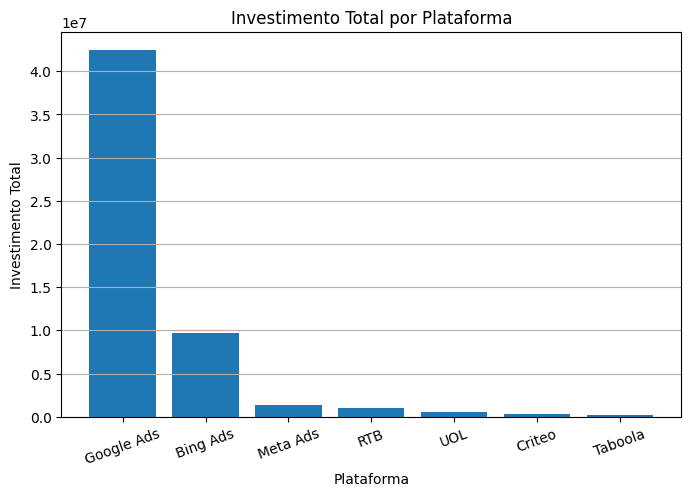

In [94]:
investimento_plataforma = tratada.groupby("platform")["investimento"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(investimento_plataforma.index, investimento_plataforma.values)
plt.title("Investimento Total por Plataforma")
plt.xlabel("Plataforma")
plt.ylabel("Investimento Total")
plt.xticks(rotation=20)
plt.grid(True, axis="y")
plt.show()

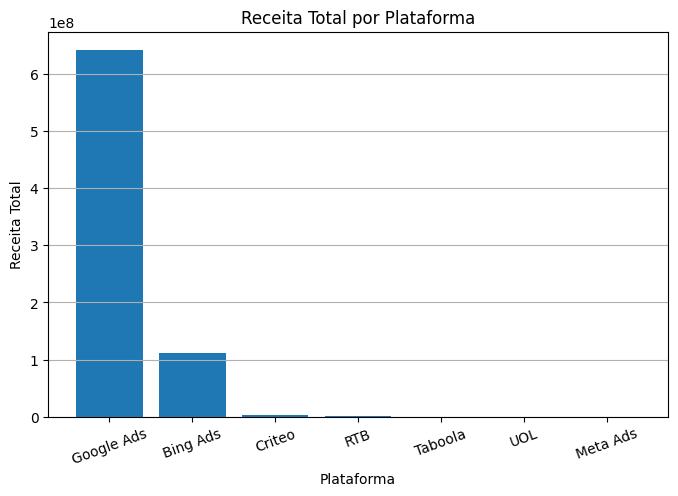

In [95]:
receita_plataforma = tratada.groupby("platform")["receita"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(receita_plataforma.index, receita_plataforma.values)
plt.title("Receita Total por Plataforma")
plt.xlabel("Plataforma")
plt.ylabel("Receita Total")
plt.xticks(rotation=20)
plt.grid(True, axis="y")
plt.show()

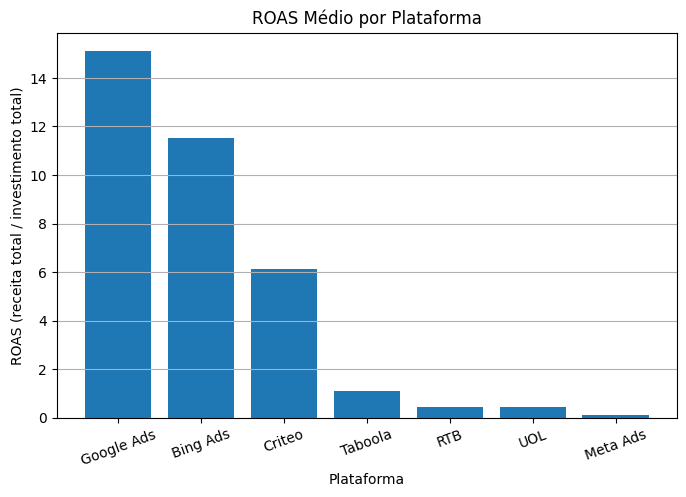

In [96]:
roas_medio_plataforma = plataforma_variaveis["roas_medio"].sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(roas_medio_plataforma.index, roas_medio_plataforma.values)
plt.title("ROAS Médio por Plataforma")
plt.xlabel("Plataforma")
plt.ylabel("ROAS (receita total / investimento total)")
plt.xticks(rotation=20)
plt.grid(True, axis="y")
plt.show()

Em geral Google Ads teve as maiores e melhores métricas

Bing Ads 

## 4.3 Análise por Data (Mês / Dia)

In [97]:
df_por_data = tratada.sort_values(by="report_date")
df_por_data.head()

,report_date,campaign_key,campaign_name,platform,campaign_group,funnel_stage,campaign_key_type,receita,orders,visits,...,receita_outro,receita_anuncio_ambiguo,receita_nao_casado,investimento_anuncio,investimento_campanha,motivos_receita,motivos_investimento,mes,ano,ano_mes
0,2025-11-03,id|azul|google ads|6504006924,BRV_VA_GOOGLE_SEARCH_LF_AON-MARCA-BRD_PASS,Google Ads,AON-MARCA-BRD,Conversão,id,20696.29,42.00,731.00,...,0.00,0.00,0.00,36402.57,0.00,safe_ad,anuncio,11,2025,2025-11
27,2025-11-03,name|azul|bing ads|brv_va_bing_dmax_lf_aon_pass,BRV_VA_BING_DMAX_LF_AON_PASS,Bing Ads,AON,Conversão,name,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,6360.52,sem_receita,campanha,11,2025,2025-11
26,2025-11-03,id|azul|meta ads|120233220400040726,VML_VA_META_SOCIAL_MF_LEADS-AZUL-FRIDAY_PASS,Meta Ads,VML_VA_META_SOCIAL_MF_LEADS-AZUL-FRIDAY_PASS,Consideração,id,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,sem_receita,sem_investimento,11,2025,2025-11
25,2025-11-03,id|azul|google ads|18185234105,BRV_VA_GOOGLE_SEARCH_LF_AON-EUA-NBRD_PASS,Google Ads,AON-EUA-NBRD,Conversão,id,0.00,0.00,0.00,...,0.00,0.00,0.00,7929.71,0.00,sem_receita,anuncio,11,2025,2025-11
24,2025-11-03,id|azul|meta ads|120211831577200726,VML_VA_META_SOCIAL_MF_AON_PASS,Meta Ads,VML_VA_META_SOCIAL_MF_AON_PASS,Consideração,id,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,sem_receita,sem_investimento,11,2025,2025-11


In [98]:
ano_mes = tratada.groupby('ano_mes')['receita']
ano_mes.sum()

ano_mes
2025-11    15205528.66
2025-12    19889516.07
2026-01    52533343.31
2026-02    87176810.40
2026-03   109194575.70
2026-04   103815926.07
2026-05    99785863.45
2026-06    80573031.63
2026-07    69739956.15
2026-08   118613242.61
Name: receita, dtype: float64

In [99]:
receita_mensal = tratada.groupby("ano_mes")["receita"].sum()

pct_receita_mensal = (receita_mensal / tratada["receita"].sum()) * 100
pct_receita_mensal

ano_mes
2025-11    2.01
2025-12    2.63
2026-01    6.94
2026-02   11.52
2026-03   14.43
2026-04   13.72
2026-05   13.19
2026-06   10.65
2026-07    9.22
2026-08   15.68
Name: receita, dtype: float64

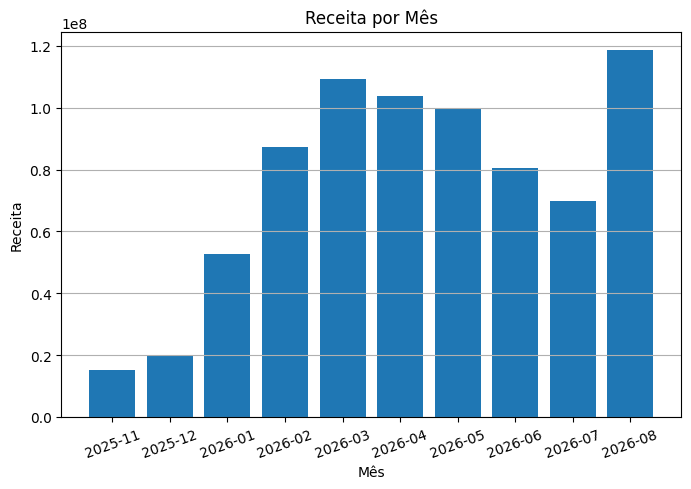

In [100]:
receita_mensal = tratada.groupby("ano_mes")["receita"].sum()

plt.figure(figsize=(8,5))
plt.bar(receita_mensal.index, receita_mensal.values)
plt.title("Receita por Mês")
plt.xlabel("Mês")
plt.ylabel("Receita")
plt.xticks(rotation=20)
plt.grid(True, axis="y")
plt.show()

In [101]:
mensal = tratada.groupby('mes').agg(
    receita=('receita', 'sum'),
    investimento=('investimento', 'sum'),
    pedidos=('orders', 'sum'),
    dias=('report_date', 'nunique'),
)
mensal['roas_mensal'] = mensal['receita'] / mensal['investimento']
display(mensal)


,receita,investimento,pedidos,dias,roas_mensal
mes,,,,,
1,52533343.31,3914053.38,31941.00,31,13.42
2,87176810.40,4282808.56,53398.00,28,20.36
3,109194575.70,7877464.75,62069.00,31,13.86
4,103815926.07,5559413.68,58268.00,30,18.67
5,99785863.45,4702244.18,58477.00,31,21.22
6,80573031.63,5733084.86,47927.00,30,14.05
7,69739956.15,4412627.11,43881.00,31,15.80
8,118613242.61,4518598.99,63152.00,31,26.25
11,15205528.66,8983283.04,8507.00,28,1.69


In [102]:
testemes_funil = tratada.groupby(['ano_mes', 'funnel_stage'])[['receita', 'investimento']].sum()
print("Top combinações mês + etapa do funil:")
testemes_funil.sort_values("receita", ascending=False).head(10)

Top combinações mês + etapa do funil:


,,receita,investimento
ano_mes,funnel_stage,,
2026-08,Conversão,118613038.05,4474393.74
2026-03,Conversão,109149113.00,7711547.59
2026-04,Conversão,103802505.70,5443004.42
2026-05,Conversão,99785863.45,4549600.06
2026-02,Conversão,87157485.92,3764563.65
2026-06,Conversão,80573031.63,5694695.30
2026-07,Conversão,69739956.15,4369540.07
2026-01,Conversão,52493532.59,3316141.73
2025-12,Conversão,19836727.85,4682172.82


In [103]:
receita_por_data = tratada.groupby('report_date')[['receita', 'investimento']].sum().sort_values(by='receita', ascending=False)
receita_por_data.head(20)

,receita,investimento
report_date,,
2026-08-11,5364414.85,151510.81
2026-03-31,5161326.70,299120.32
2026-08-17,5079544.22,146257.67
2026-08-26,4931045.02,132763.79
2026-08-31,4921607.41,213769.45
2026-08-19,4837634.13,123853.86
2026-08-12,4794835.31,154813.64
2026-08-24,4710706.58,142474.55
2026-04-01,4639987.50,293218.61


,receita_safe_ad,receita_excecao_manual,receita_pmax_sem_anuncio,receita_por_nome_campanha,receita_anuncio_ambiguo
ano_mes,,,,,
2025-11,14.40,0.00,5.12,68.17,12.31
2025-12,11.28,0.00,12.01,55.16,21.55
2026-01,3.35,52.53,19.23,23.92,0.97
2026-02,0.57,72.53,13.82,11.66,1.42
2026-03,7.86,68.42,8.96,12.01,2.74
2026-04,1.47,76.16,8.50,10.96,2.91
2026-05,1.96,72.55,11.08,11.73,2.68
2026-06,2.45,74.36,7.67,12.62,2.91
2026-07,4.54,20.28,6.60,13.22,55.36


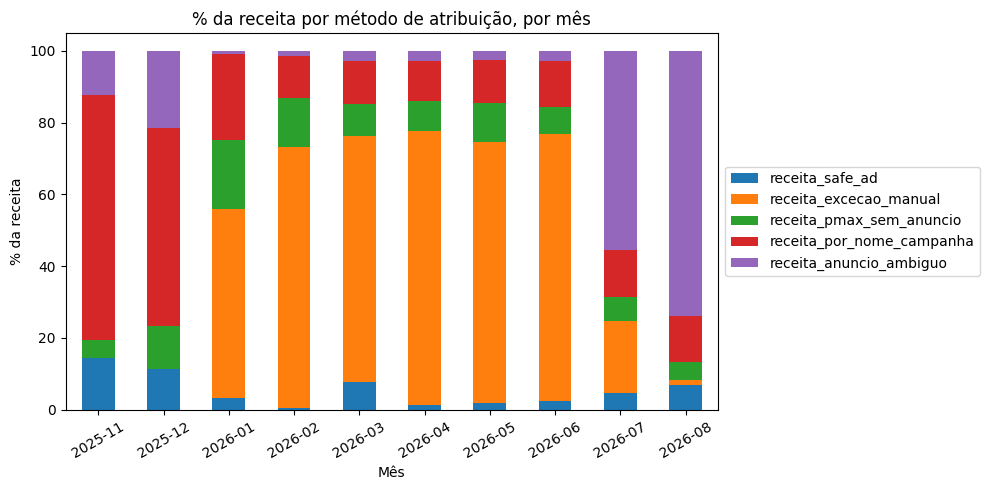

In [104]:
metodos = ['receita_safe_ad', 'receita_excecao_manual', 'receita_pmax_sem_anuncio',
           'receita_por_nome_campanha', 'receita_anuncio_ambiguo']

mix_mes = tratada.groupby('ano_mes')[metodos + ['receita']].sum()
mix_mes_pct = mix_mes[metodos].div(mix_mes['receita'], axis=0) * 100
display(mix_mes_pct)

mix_mes_pct.plot(kind='bar', stacked=True, figsize=(10, 5))
plt.title("% da receita por método de atribuição, por mês")
plt.ylabel("% da receita")
plt.xlabel("Mês")
plt.xticks(rotation=30)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

## 4.4 Análise do Funnel Stage

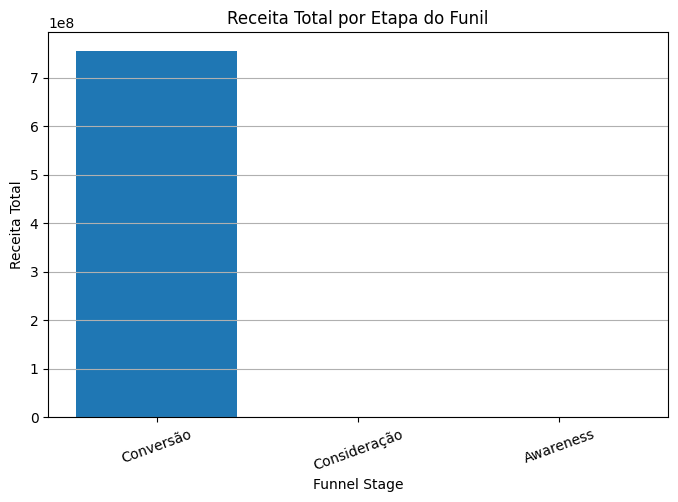

In [105]:
receita_funil = tratada.groupby("funnel_stage")["receita"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(receita_funil.index, receita_funil.values)
plt.title("Receita Total por Etapa do Funil")
plt.xlabel("Funnel Stage")
plt.ylabel("Receita Total")
plt.xticks(rotation=20)
plt.grid(True, axis="y")
plt.show()

In [106]:
tratada['funnel_stage'].value_counts()

funnel_stage
Conversão       16625
Consideração     1168
Awareness         199
Name: count, dtype: int64

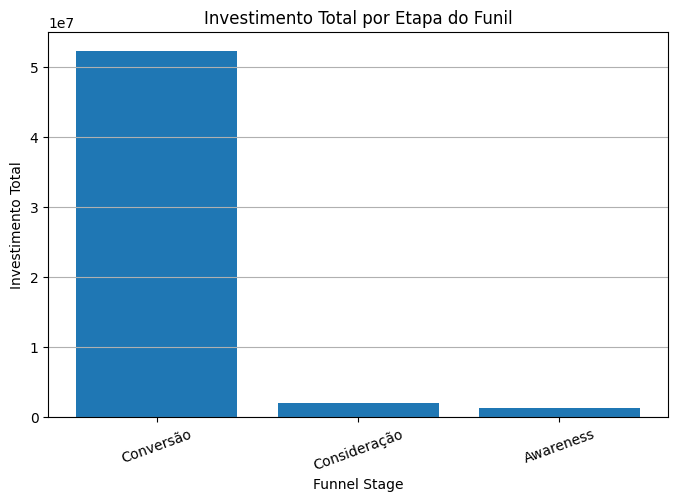

In [108]:
investimento_funil = tratada.groupby("funnel_stage")["investimento"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(investimento_funil.index, investimento_funil.values)
plt.title("Investimento Total por Etapa do Funil")
plt.xlabel("Funnel Stage")
plt.ylabel("Investimento Total")
plt.xticks(rotation=20)
plt.grid(True, axis="y")
plt.show()

Receita, investimento e ROAS por etapa:

In [109]:
funil_resumo = tratada.groupby("funnel_stage")[["receita", "investimento"]].sum()
funil_resumo["roas_etapa"] = funil_resumo["receita"] / funil_resumo["investimento"]
funil_resumo["pct_receita"] = funil_resumo["receita"] / funil_resumo["receita"].sum() * 100
funil_resumo["pct_investimento"] = funil_resumo["investimento"] / funil_resumo["investimento"].sum() * 100
funil_resumo.sort_values("roas_etapa", ascending=False)

,receita,investimento,roas_etapa,pct_receita,pct_investimento
funnel_stage,,,,,
Conversão,756321266.46,52331921.08,14.45,99.97,93.93
Consideração,206527.59,2021735.24,0.10,0.03,3.63
Awareness,0.00,1360533.66,0.00,0.00,2.44


In [111]:
tratada[tratada['platform'] == 'Meta Ads']['campaign_name'].value_counts().head(15)

campaign_name
BRV_VA_META_FEED_LF_ANOITECEU_PASS                        200
BRV_VA_META_FEED_LF_NOVAS-ROTAS_PASS                      193
BRV_VA_META_FEED_LF_SAZONAL_PASS                          180
BRV_VA_META_FEED_LF_ROTAS-INTERNACIONAIS_PASS             162
BRV_VA_META_FEED_LF_OFERTAS-AZUL_PASS                     144
BRV_VA_META_FEED_LF_DATA-DUPLA_PASS                        85
BRV_VA_META_FEED_LF_COPA-DO-MUNDO_PASS                     84
BRV_VA_META_FEED_LF_COMPET_PASS                            68
BRV_VA_META_SOCIAL_LF_15OFF-PIX_PASS                       56
BRV_VA_META_SOCIAL_LF_FIM-DE-ANO_PASS                      49
BRV_VA_META_FEED_LF_DESCONTACO_PASS                        46
BRV_VA_META_FEED_LF_AON-MARCA_PASS                         43
BRV_VA_META_SOCIAL_LF_AON-ALTA-TEMPORADA-CARNAVAL_PASS     42
BRV_VA_META_SOCIAL_LF_PROMO-DESTINO_PONTOS                 30
BRV_VA_META_FEED_LF_MES-CONSUMIDOR_PASS                    28
Name: count, dtype: int64

## 4.5 Outras observações (motivos e assertividade)

In [115]:
print(tratada["motivos_receita"].value_counts())

motivos_receita
por_nome_campanha                                          5552
sem_receita                                                3952
safe_ad                                                    3241
pmax_sem_anuncio                                           1912
anuncio_ambiguo                                            1348
anuncio_ambiguo,pmax_sem_anuncio,safe_ad                    566
anuncio_ambiguo,safe_ad                                     506
pmax_sem_anuncio,safe_ad                                    356
anuncio_ambiguo,pmax_sem_anuncio                            335
anuncio_ambiguo,excecao_manual,safe_ad                      156
anuncio_ambiguo,excecao_manual,pmax_sem_anuncio,safe_ad      55
excecao_manual,safe_ad                                       13
Name: count, dtype: int64


In [116]:
print(tratada["motivos_investimento"].value_counts())

motivos_investimento
sem_investimento      6620
campanha              5514
anuncio               4882
anuncio + campanha     976
Name: count, dtype: int64


## 4.6 Groupbys — o que afeta a receita (base `tratada`)

Função auxiliar pra não repetir código em cada groupby: soma receita e investimento, calcula ROAS do grupo, ordena pela receita.

In [148]:
def resumo_por(grupo_col, top=15):
    g = tratada.groupby(grupo_col).agg(
        linhas=('receita', 'size'),
        receita=('receita', 'sum'),
        investimento=('investimento', 'sum'),
    )
    g['roas'] = g['receita'] / g['investimento'].replace(0, pd.NA)
    return g.sort_values('receita', ascending=False).head(top)

### Por plataforma

In [149]:
resumo_por('platform')

,linhas,receita,investimento,roas
platform,,,,
Google Ads,8543,641676595.57,42467207.96,15.11
Bing Ads,5285,111548810.81,9685066.56,11.52
Criteo,253,2175400.91,355868.59,6.11
RTB,898,469783.47,1040628.22,0.45
Taboola,976,268102.94,247168.79,1.08
UOL,502,247796.16,588621.77,0.42
Meta Ads,1535,141304.19,1329628.09,0.11


Google Ads e Bing Ads concentram praticamente toda a receita (R$ 641M + R$ 112M de R$ 756M do total). Meta Ads, RTB e UOL têm ROAS abaixo de 1 — gastam mais do que atribuem de volta.

### Por etapa do funil

In [150]:
resumo_por('funnel_stage')

,linhas,receita,investimento,roas
funnel_stage,,,,
Conversão,16625,756321266.46,52331921.08,14.45
Consideração,1168,206527.59,2021735.24,0.10
Awareness,199,0.00,1360533.66,0.00


Conversão concentra 100% da receita (R$ 756M). Awareness e Consideração têm receita ~zero — confirma o que já sabíamos: só faz sentido olhar receita na etapa de Conversão.

### Por mês

In [151]:
resumo_por('mes')

,linhas,receita,investimento,roas
mes,,,,
8,2649,118613242.61,4518598.99,26.25
3,1684,109194575.70,7877464.75,13.86
4,1781,103815926.07,5559413.68,18.67
5,2242,99785863.45,4702244.18,21.22
2,1286,87176810.40,4282808.56,20.36
6,2399,80573031.63,5733084.86,14.05
7,2813,69739956.15,4412627.11,15.80
1,1094,52533343.31,3914053.38,13.42
12,1167,19889516.07,5730611.44,3.47


Agosto (mês 8) é o melhor mês em receita (R$ 118,6M) e ROAS (26,2). Novembro (mês 11) é o pior em receita e ROAS (1,69) — confirma a correção da hipótese anterior: novembro não foi o melhor mês, foi o pior.

### Por motivo de receita (`motivos_receita`)

In [152]:
resumo_por('motivos_receita')

,linhas,receita,investimento,roas
motivos_receita,,,,
"anuncio_ambiguo,excecao_manual,safe_ad",156,380039554.44,11769285.13,32.29
"anuncio_ambiguo,excecao_manual,pmax_sem_anuncio,safe_ad",55,133783222.31,3381881.09,39.56
por_nome_campanha,5552,114709894.29,6177133.66,18.57
pmax_sem_anuncio,1912,69597931.73,9177894.27,7.58
"excecao_manual,safe_ad",13,20767048.59,876791.71,23.69
"anuncio_ambiguo,pmax_sem_anuncio,safe_ad",566,12196976.84,3486570.19,3.50
"anuncio_ambiguo,safe_ad",506,7720249.82,3322101.28,2.32
"anuncio_ambiguo,pmax_sem_anuncio",335,5667453.83,513932.21,11.03
safe_ad,3241,5487517.40,2444275.75,2.25


`por_nome_campanha` sozinho já responde por boa parte da receita (5.552 linhas). Combinações com `anuncio_ambiguo` têm ROAS mais instável — em alguns casos altíssimo (ex: 32–39), sinal de poucas linhas com valor concentrado, vale checar outlier antes de generalizar. `sem_receita` (nulo original) é a segunda maior contagem de linhas (4.013), mas contribuição zero de receita, como esperado.

### Por grupo de campanha (`campaign_group`)

In [153]:
resumo_por('campaign_group')

,linhas,receita,investimento,roas
campaign_group,,,,
AON-MARCA-BRD,545,559561420.16,22518715.19,24.85
MARCA,302,72072376.46,1249910.57,57.66
AON-MARCA,588,61818642.74,6589639.24,9.38
AON-CONCORRENTES-NBRD,541,6088678.34,2127803.00,2.86
AON,862,5987214.62,1585006.81,3.78
AON-US-PASSENGER-BRD,540,5657533.54,438958.51,12.89
CONCORRENTES,299,5126061.91,934597.14,5.48
AON-GENERICA-NBRD,542,4564426.67,2453231.35,1.86
COPA-DO-MUNDO,890,3694812.55,1258863.68,2.94


`AON-MARCA-BRD` é o maior grupo em receita absoluta (R$ 560M), mas `MARCA` tem o melhor ROAS (57,6) com bem menos investimento — campanha de marca (branded search) tende a ser muito eficiente porque a pessoa já está buscando pela Azul.

### Por nome de campanha (`campaign_name`)

In [154]:
resumo_por('campaign_name')

,linhas,receita,investimento,roas
campaign_name,,,,
BRV_VA_GOOGLE_SEARCH_LF_AON-MARCA-BRD_PASS,302,544169947.31,20001589.63,27.21
BRV_VA_BING_SEARCH_LF_MARCA_PASS,302,72072376.46,1249910.57,57.66
BRV_VA_GOOGLE_PMAX_LF_AON-MARCA_PASS,302,60001780.13,5895171.85,10.18
BRV_VA_BING_SEARCH_LF_AON-MARCA-BRD_PASS,243,15391472.85,2517125.56,6.11
BRV_VA_BING_DMAX_LF_AON_PASS,301,5987214.62,413700.67,14.47
BRV_VA_GOOGLE_SEARCH_LF_AON-CONCORRENTES-NBRD_PASS,302,5792486.70,1559882.79,3.71
BRV_VA_GOOGLE_SEARCH_LF_AON-US-PASSENGER-BRD_PASS,298,5264948.33,360228.22,14.62
BRV_VA_BING_SEARCH_LF_CONCORRENTES_PASS,299,5126061.91,934597.14,5.48
BRV_VA_GOOGLE_SEARCH_LF_AON-GENERICA-NBRD_PASS,302,4460989.40,2212391.41,2.02


No nível mais granular, o padrão se confirma: campanhas de busca por marca (`SEARCH_LF_MARCA`, `SEARCH_LF_AON-MARCA-BRD`) dominam tanto em receita quanto em ROAS. Vale reparar que muitas dessas têm ~300 linhas cada (uma por dia, ao longo de todo o período) — são campanhas contínuas, não pontuais.

### Por `campaign_key` (id/nome técnico da campanha)

In [155]:
resumo_por('campaign_key')

,linhas,receita,investimento,roas
campaign_key,,,,
id|azul|google ads|6504006924,302,544169947.31,20001589.63,27.21
name|azul|bing ads|brv_va_bing_search_lf_marca_pass,302,72072376.46,1249910.57,57.66
id|azul|google ads|20417584768,302,60001780.13,5895171.85,10.18
name|azul|bing ads|brv_va_bing_search_lf_aon-marca-brd_pass,243,15391472.85,2517125.56,6.11
name|azul|bing ads|brv_va_bing_dmax_lf_aon_pass,301,5987214.62,413700.67,14.47
id|azul|google ads|18482497357,302,5792486.70,1559882.79,3.71
id|azul|google ads|20508311506,298,5264948.33,360228.22,14.62
name|azul|bing ads|brv_va_bing_search_lf_concorrentes_pass,299,5126061.91,934597.14,5.48
id|azul|google ads|11382534426,302,4460989.40,2212391.41,2.02


Mesmo ranking de cima, mas com o identificador técnico — útil se depois for cruzar com outra base que só tenha o `campaign_key`, não o nome legível.

### Por dia 

Melhores dias:

In [146]:
receita_dia = tratada.groupby('report_date').agg(
    receita=('receita', 'sum'),
    investimento=('investimento', 'sum'),
)
receita_dia['roas'] = receita_dia['receita'] / receita_dia['investimento'].replace(0, pd.NA)
display(receita_dia.sort_values('receita', ascending=False).head(10))


,receita,investimento,roas
report_date,,,
2026-08-11,5364414.85,151510.81,35.41
2026-03-31,5161326.70,299120.32,17.26
2026-08-17,5079544.22,146257.67,34.73
2026-08-26,4931045.02,132763.79,37.14
2026-08-31,4921607.41,213769.45,23.02
2026-08-19,4837634.13,123853.86,39.06
2026-08-12,4794835.31,154813.64,30.97
2026-08-24,4710706.58,142474.55,33.06
2026-04-01,4639987.50,293218.61,15.82


Piores dias:

In [145]:
display(receita_dia.sort_values('receita').head(10))

,receita,investimento,roas
report_date,,,
2025-11-03,39494.21,334014.08,0.12
2025-11-05,48531.12,400719.78,0.12
2025-11-06,92262.19,238806.81,0.39
2025-11-04,112063.86,265501.42,0.42
2025-12-13,324427.83,226174.82,1.43
2025-12-06,339002.09,440705.23,0.77
2025-12-21,354512.06,73750.34,4.81
2025-12-25,367393.79,71113.88,5.17
2026-01-11,369350.48,23017.22,16.05


Os melhores dias estão quase todos em agosto de 2026. Os piores dias estão concentrados no início de novembro de 2025 (03 a 06/11) receita muito baixa com investimento relativamente alto.